# Instacart Market Basket Analysis: Machine Learning Pipeline

This notebook demonstrates a complete end-to-end Machine Learning pipeline to predict which products a user will buy in their next order on Instacart. We use three different modeling paradigms taught in class:
1. **Matrix Factorization (NCF)** using **MindSpore** eager mode (Neural Collaborative Filtering with user and item embeddings).
2. **XGBoost Classifier** with engineered features (including the Matrix Factorization score fed as a feature).
3. **Sequential Transformer Encoder** using **MindSpore** to model order-level chronological sequences.

### Environment Setup
- Frameworks: **MindSpore 2.9.0** (CPU) & **XGBoost 3.3.0**
- Run Kernel: **Instacart ML Environment** (configured in `.venv` to avoid version conflicts)
- Hardware Target: CPU (optimized with numpy batching to prevent graph deadlocks on Windows)


## 0. Setup and Imports
Let's import the necessary libraries and verify that MindSpore is configured correctly for eager mode on CPU.


In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mindspore as ms
import mindspore.ops as ops

# Set MindSpore eager mode on CPU
ms.set_context(mode=ms.PYNATIVE_MODE, device_target="CPU")
print("MindSpore version:", ms.__version__)
print("Platform CPU check:")
ms.run_check()


[WARNING] ME(28440:18784,MainProcess):2026-06-29-16:08:48.440.000 [mindspore\run_check\_check_version.py:523] The directory C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8 does not contain the typical file structure of CUDA
[ERROR] ME(28440:18784,MainProcess):2026-06-29-16:08:48.441.000 [mindspore\run_check\_check_version.py:562] CUDA_PATH C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.8 is not safe, skip add cuda path.
[WARNING] ME(28440:18784,MainProcess):2026-06-29-16:08:50.600.0 [mindspore\context.py:1338] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


MindSpore version: 2.9.0
Platform CPU check:
MindSpore version:  2.9.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [CPU] successfully!


## 1. Data Preprocessing & Downsampling

The original dataset has **32.4 million purchases** across **206,209 users**. Training deep learning models on a CPU on the full dataset is highly memory-intensive.
Here, we sample **5,000 random users** who have train orders, and extract their complete purchase history. We split them into **80% training users (4,000)** and **20% validation users (1,000)**.
This results in ~800k prior purchases, which allows fast training (less than 4 minutes total).


In [2]:
from src import config
from src.data_preprocessing import run_preprocessing

# Run preprocessing (skips if already generated in data/processed/ folder)
run_preprocessing(force=False)

# Show data dimensions
orders = pd.read_csv(config.ORDERS_SAMPLE_PATH)
prior_prods = pd.read_csv(config.PRIOR_PRODUCTS_SAMPLE_PATH)
train_prods = pd.read_csv(config.TRAIN_PRODUCTS_SAMPLE_PATH)

print(f"Sampled Orders: {len(orders)} rows")
print(f"Sampled Prior Purchases: {len(prior_prods)} rows")
print(f"Sampled Train Purchases: {len(train_prods)} rows")


Preprocessed sample files is already exist. Skip preprocessing.
Sampled Orders: 85088 rows
Sampled Prior Purchases: 804471 rows
Sampled Train Purchases: 53103 rows


### 1.1 Exploratory Data Analysis (EDA)
Let's visualize two critical properties of the Instacart dataset:
1. **Order Basket Size Distribution**: The distribution of the number of products per order.
2. **Reorder Rate vs. Add-to-Cart Position**: Showing how the order in which products are added to the cart impacts their likelihood of being reordered.

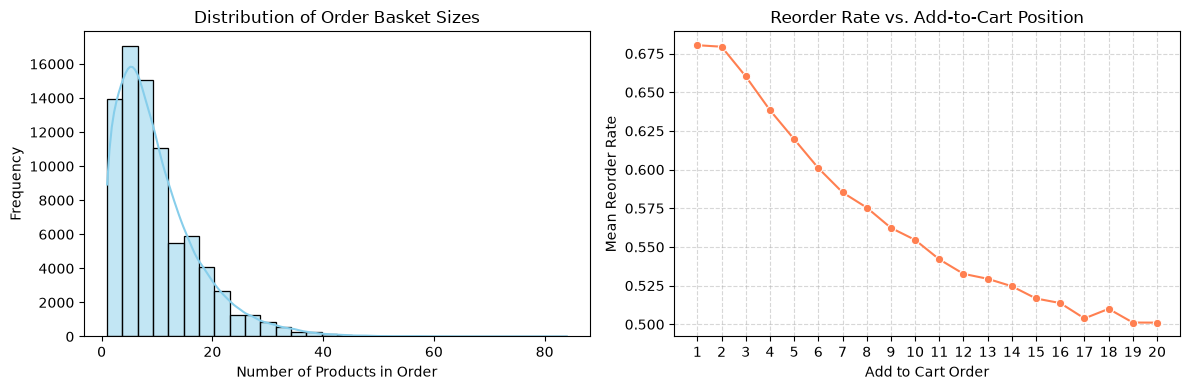

In [3]:
# print(prior_prods.shape)
# 1. Order Basket Size Distribution
basket_sizes = prior_prods.groupby('order_id').size()
# print(basket_sizes.describe())
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(basket_sizes, bins=30, kde=True, color='skyblue')
plt.title('Distribution of Order Basket Sizes')
plt.xlabel('Number of Products in Order')
plt.ylabel('Frequency')

# 2. Reorder Rate vs. Add-to-Cart Position
reorder_by_pos = prior_prods.groupby('add_to_cart_order')['reordered'].mean().reset_index()
# Filter to first 20 items to focus on typical cart sizes
reorder_by_pos = reorder_by_pos[reorder_by_pos['add_to_cart_order'] <= 20]
plt.subplot(1, 2, 2)
sns.lineplot(x='add_to_cart_order', y='reordered', data=reorder_by_pos, marker='o', color='coral')
plt.title('Reorder Rate vs. Add-to-Cart Position')
plt.xlabel('Add to Cart Order')
plt.ylabel('Mean Reorder Rate')
plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 2. Matrix Factorization (Neural Collaborative Filtering)

We train a Collaborative Filtering model in MindSpore by mapping user IDs and product IDs to a low-dimensional embedding space ($D=64$).
We perform **negative sampling** (4 negative products per positive purchase) and optimize the model using BCE loss to predict user affinity scores for products.
The trained model predictions will be saved and passed to XGBoost as a collaborative feature.


In [4]:
from src.matrix_factorization import train_matrix_factorization, load_mf_model_and_mappings

# Train NCF model in MindSpore (5 epochs)
train_matrix_factorization()

# Load model and mappings
mf_model, mf_mappings = load_mf_model_and_mappings()
print(f"MF Model loaded successfully. User vocabulary size: {mf_mappings['num_users']}, Product vocabulary size: {mf_mappings['num_products_vocab']}")


[WARNING] ME(28440:18784,MainProcess):2026-06-29-16:08:51.418.000 [mindspore\context.py:1338] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


Preparing data for Matrix Factorization...
Positive interaction pairs: 326778
Sampling negative user-product pairs...
Negative sampling completed. Corrected 5309 collisions.


[WARNING] ME(28440:18784,MainProcess):2026-06-29-16:08:53.112.000 [mindspore\common\_decorator.py:69] 'FusedSparseAdam' is deprecated from version 2.8.0 and will be removed in a future version.


Training MindSpore Matrix Factorization model...
Epoch 1/5: Loss = 0.4041
Epoch 2/5: Loss = 0.2551
Epoch 3/5: Loss = 0.1483
Epoch 4/5: Loss = 0.0773
Epoch 5/5: Loss = 0.0426
Matrix Factorization model save to c:\Users\chenj\OneDrive\Desktop\UUU\Machine Learning\Project\code\data\processed\mf_model.ckpt
MF Model loaded successfully. User vocabulary size: 5000, Product vocabulary size: 49689


### 2.1 Matrix Factorization Training Learning Curve
Let's visualize the training loss of our MindSpore Matrix Factorization model over the 5 epochs of training to check convergence.

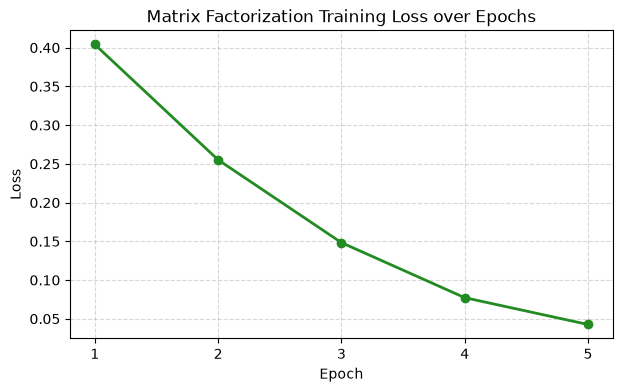

In [5]:
# print("loss len:", len(mf_mappings['loss_history']))
epochs_range = range(1, len(mf_mappings['loss_history']) + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, mf_mappings['loss_history'], marker='o', color='forestgreen', linewidth=2)
plt.title('Matrix Factorization Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.5)
# plt.savefig('mf_loss.png')
plt.show()


## 3. Feature Engineering & XGBoost Classifier

For each user's next order, candidate products are products they bought in prior orders. For each candidate (User, Product), we extract:
1. **User features**: total orders, average basket size, user reorder rate, average days since prior order.
2. **Product features**: total sales count, product reorder rate, average add-to-cart position.
3. **User-Product interaction features**: total times user bought this product, purchase rate, last order distance, average add-to-cart position.
4. **Collaborative Filtering feature**: the predicted affinity score from our MindSpore Matrix Factorization model.

We train XGBoost and sweep the decision threshold on validation set to find the optimal Mean F1-score.


In [6]:
from src.xgboost_model import train_xgboost

# Train XGBoost Classifier (includes MF score loading and candidate extraction)
xgb_model, xgb_metrics = train_xgboost()


Extracting features and generating candidates for XGBoost...
Computing User features...
Computing Product features...
Computing User-Product interaction features...
Generating candidate user-product pairs...
Merging features into candidates...
Generating targets...
Adding Matrix Factorization interaction scores...
Features list: ['user_total_orders', 'user_avg_basket_size', 'user_reorder_rate', 'user_avg_days_since_prior_order', 'product_total_orders', 'product_reorder_rate', 'product_avg_add_to_cart', 'up_total_orders', 'up_avg_add_to_cart', 'up_purchase_rate', 'up_last_order_distance', 'mf_score']
XGBoost Train shape: (263072, 12), Val shape: (63706, 12)
Training XGBoost Classifier...
[0]	validation_0-logloss:0.30058
[20]	validation_0-logloss:0.25453
[40]	validation_0-logloss:0.24587
[60]	validation_0-logloss:0.24370
[80]	validation_0-logloss:0.24313
[100]	validation_0-logloss:0.24301
[120]	validation_0-logloss:0.24306
[140]	validation_0-logloss:0.24307
[149]	validation_0-logloss:0.2

### 3.1 XGBoost Training History and Threshold Optimization
Let's visualize the training convergence of XGBoost (validation loss decreasing over boosting rounds) alongside the F1-Score threshold optimization curve to see how the optimal threshold was selected.

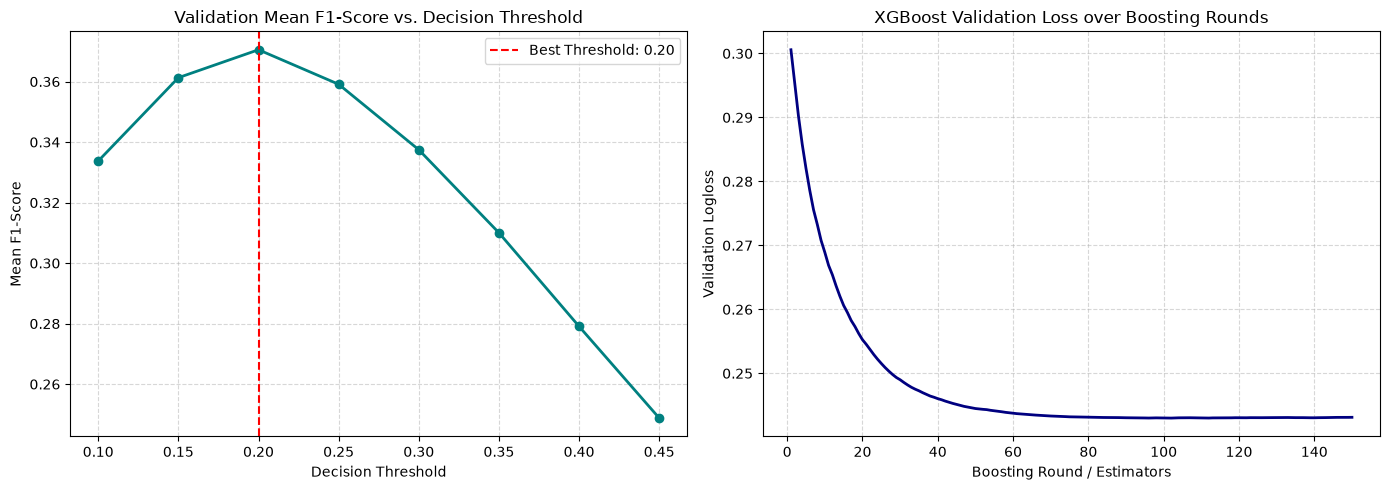

In [7]:
# print(xgb_metrics['threshold_sweeps'])
plt.figure(figsize=(14, 5))

# Subplot 1: Threshold Sweep
thresholds, f1_scores = zip(*xgb_metrics['threshold_sweeps'])
plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores, marker='o', color='teal', linewidth=2)
plt.axvline(x=xgb_metrics['best_threshold'], color='red', linestyle='--', label=f"Best Threshold: {xgb_metrics['best_threshold']:.2f}")
plt.title('Validation Mean F1-Score vs. Decision Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Mean F1-Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Subplot 2: XGBoost Training Learning Curve (Logloss)
plt.subplot(1, 2, 2)
logloss_history = xgb_metrics['loss_history']
# print("total boosting rounds:", len(logloss_history))
plt.plot(range(1, len(logloss_history) + 1), logloss_history, color='navy', linewidth=2)
plt.title('XGBoost Validation Loss over Boosting Rounds')
plt.xlabel('Boosting Round / Estimators')
plt.ylabel('Validation Logloss')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
# plt.savefig('xgb_plots.png')
plt.show()


## 4. Sequential Transformer Model

We model each user's purchase history as a sequence of orders: $O_1, O_2, \dots, O_{T-1}$.
Each order $O_t$ is embedded by taking the average of its product embeddings. We add learned position embeddings and pass the sequence through a **MindSpore Transformer Encoder**.
The final user state is projected to predict the probabilities of all products in the vocabulary for the target order $O_T$.


In [8]:
from src.transformer_model import train_transformer

# Train Transformer model in MindSpore (5 epochs)
tf_model, tf_metrics = train_transformer()


[WARNING] ME(28440:18784,MainProcess):2026-06-29-16:10:02.640.00 [mindspore\context.py:1338] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


Preparing order sequence data for Transformer...
Training MindSpore Sequential Transformer model...
Epoch 1/5: Loss = 0.6013
Epoch 2/5: Loss = 0.4102
Epoch 3/5: Loss = 0.2707
Epoch 4/5: Loss = 0.1788
Epoch 5/5: Loss = 0.1219
Transformer model save to c:\Users\chenj\OneDrive\Desktop\UUU\Machine Learning\Project\code\data\processed\transformer_model.ckpt
Evaluating Transformer model on validation set...
Computing validation metrics...
Validation Mean User ROC AUC: 0.5505
Validation Mean User F1-score (Top 10): 0.0232


### 4.1 Transformer Training Learning Curve
Let's visualize the training loss of our MindSpore Sequential Transformer over the 5 epochs of training to check convergence.

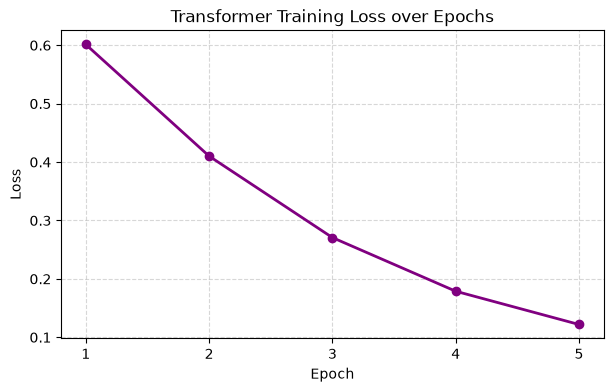

In [9]:
# print("tf loss shape:", len(tf_metrics['loss_history']))
epochs_range = range(1, len(tf_metrics['loss_history']) + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, tf_metrics['loss_history'], marker='o', color='purple', linewidth=2)
plt.title('Transformer Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.5)
# plt.savefig('tf_loss.png')
plt.show()


## 5. Model Evaluation and Comparison

Let's load the results of all models and compare their ROC AUC, Mean F1-score, and training speeds.
We also evaluate the Matrix Factorization model directly on the validation candidates to get a baseline.


In [10]:
from src.train_all import evaluate_all_models

# Run unified evaluation for all models on validation candidate set
df_results = evaluate_all_models()
df_results


Running comprehensive recommendation metrics benchmarking...
Extracting features and generating candidates for XGBoost...
Computing User features...
Computing Product features...
Computing User-Product interaction features...
Generating candidate user-product pairs...
Merging features into candidates...
Generating targets...
Adding Matrix Factorization interaction scores...
Evaluating Matrix Factorization (NCF)...
Evaluating XGBoost...
Evaluating Transformer (Fair Comparison on Candidates)...
Preparing order sequence data for Transformer...


[WARNING] ME(28440:18784,MainProcess):2026-06-29-16:11:15.592.000 [mindspore\context.py:1338] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


,Model,ROC AUC,F1@K,Precision@K,Recall@K,Hit Rate@K,NDCG@K,MRR,Training Time
0,Matrix Factorization (NCF),0.551358,0.214035,0.154392,0.348770,0.756614,0.269893,0.357852,N/A
1,XGBoost (Classifier),0.822320,0.389641,0.294603,0.575196,0.922751,0.533986,0.672840,N/A
2,Sequential Transformer,0.531133,0.200587,0.143280,0.334288,0.753439,0.271598,0.406891,N/A


### Visualization of Comparison
Let's plot the comparative performance of the three models.


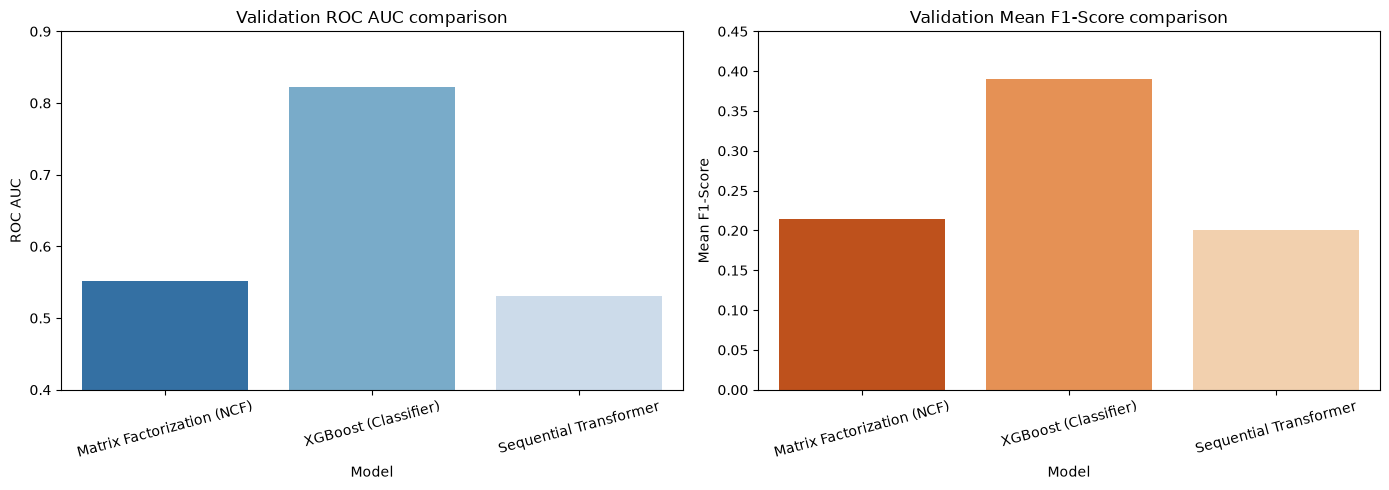

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot ROC AUC
sns.barplot(x='Model', y='ROC AUC', data=df_results, ax=axes[0], palette='Blues_r')
axes[0].set_title('Validation ROC AUC comparison')
axes[0].set_ylim(0.4, 0.9)
axes[0].set_ylabel('ROC AUC')
axes[0].set_xticklabels(df_results['Model'], rotation=15)

# Plot F1-score
sns.barplot(x='Model', y='F1@K', data=df_results, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Validation Mean F1-Score comparison')
axes[1].set_ylim(0.0, 0.45)
axes[1].set_ylabel('Mean F1-Score')
axes[1].set_xticklabels(df_results['Model'], rotation=15)

plt.tight_layout()
plt.show()


### Unified Recommendation Metrics Comparison
Let's also compare the models on the newly introduced recommendation metrics: Precision@10, Recall@10, Hit Rate@10, NDCG@10, and MRR.

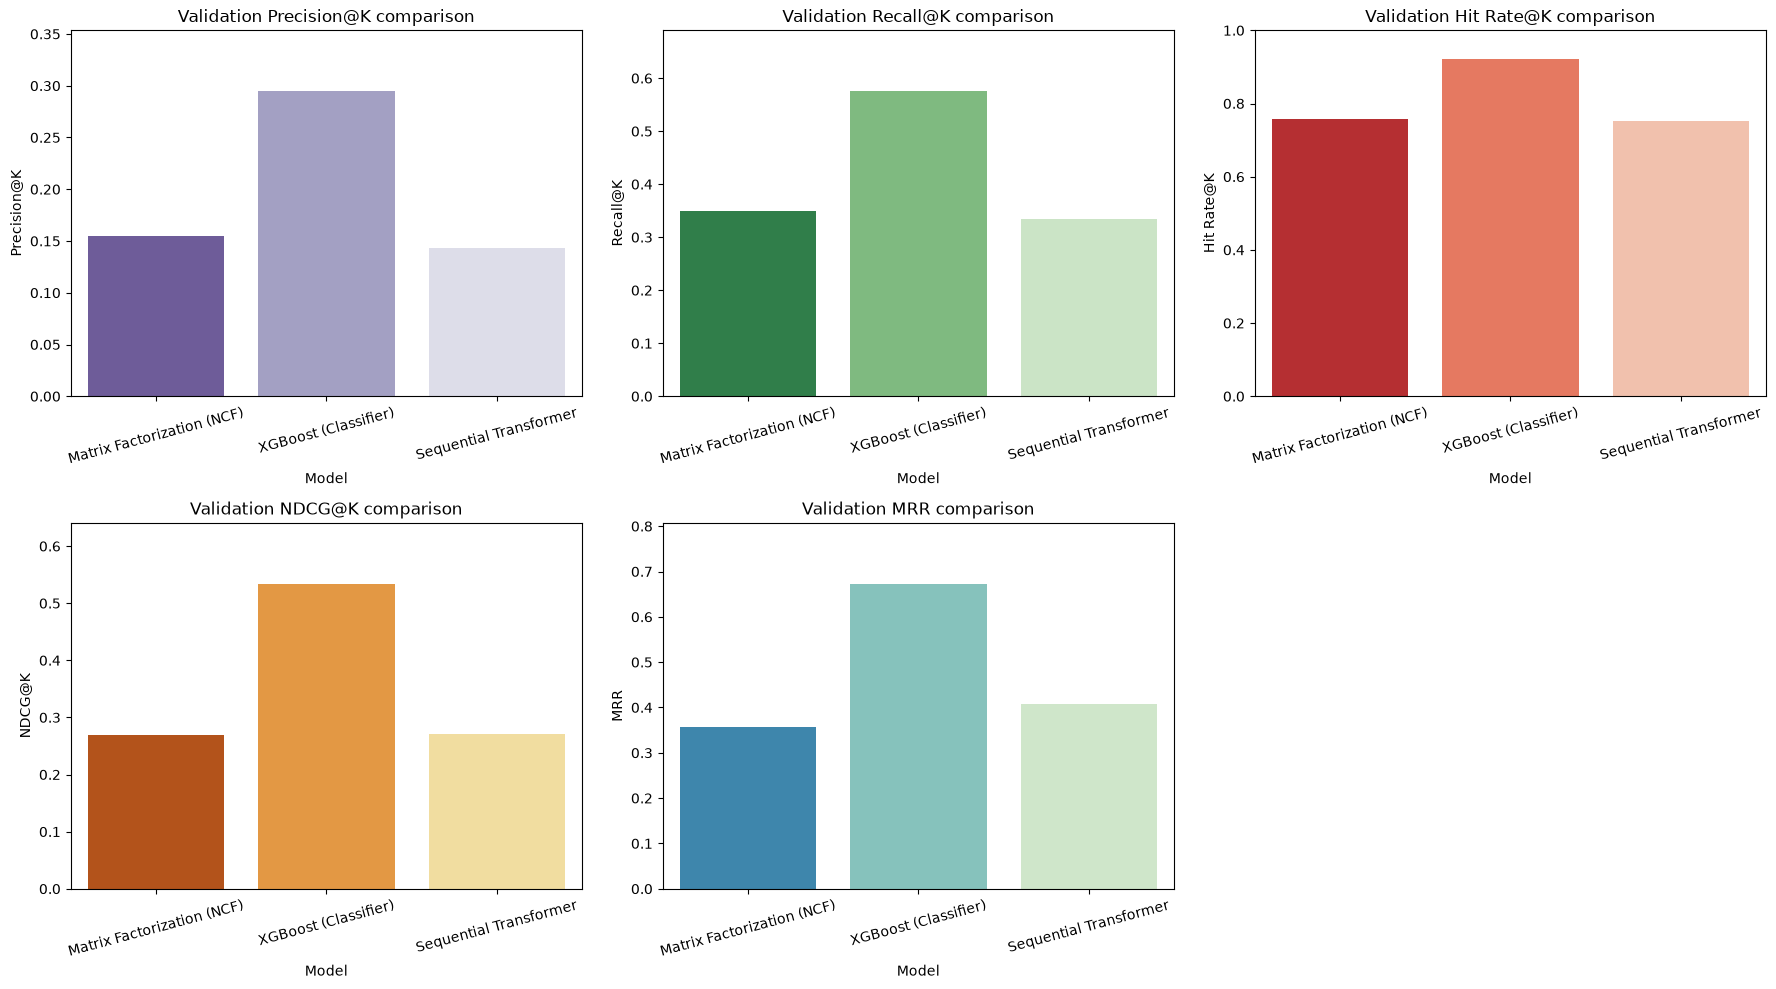

In [12]:
# Plot all recommendation metrics in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

rec_cols = ['Precision@K', 'Recall@K', 'Hit Rate@K', 'NDCG@K', 'MRR']
palettes = ['Purples_r', 'Greens_r', 'Reds_r', 'YlOrBr_r', 'GnBu_r']

for idx, col in enumerate(rec_cols):
    sns.barplot(x='Model', y=col, data=df_results, ax=axes[idx], palette=palettes[idx])
    axes[idx].set_title(f'Validation {col} comparison')
    axes[idx].set_ylabel(col)
    axes[idx].set_xticklabels(df_results['Model'], rotation=15)
    max_val = df_results[col].astype(float).max()
    axes[idx].set_ylim(0.0, min(1.0, max_val * 1.2))

# Hide the 6th empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()


### Feature Importances in XGBoost
Let's see which features were most important to our best model (XGBoost).


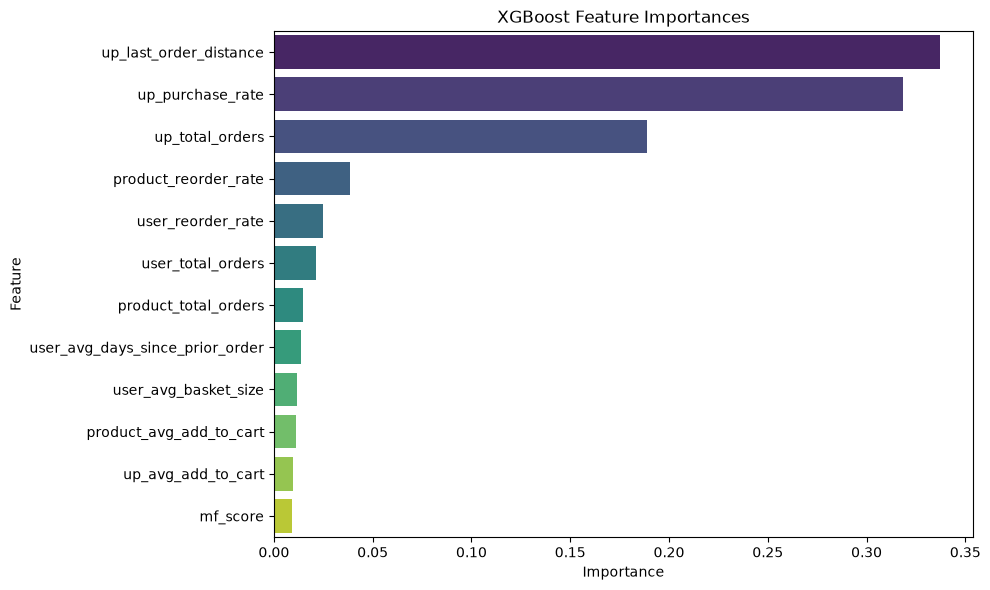

In [13]:
importances = xgb_metrics['feature_importances']
df_imp = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
